# Inspect the complete scene pipeline

This notebook creates one `SceneTrace` entirely in memory and audits every semantic boundary: pattern sampling, slot construction, class assignment, symbol realization, placement diagnostics, and final rendering.


In [1]:
from pathlib import Path
from pprint import pprint
import sys

from IPython.display import display

PROJECT_ROOT = next(
    root for root in (Path.cwd(), *Path.cwd().parents)
    if (root / '06_configs' / 'ontology.yaml').exists()
)
SCRIPTS_ROOT = PROJECT_ROOT / '01_scripts'
if str(SCRIPTS_ROOT) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_ROOT))

from generation.core.sampling import load_sampling_config
from scene import generate_scene_trace, load_audit_cases, load_scene_configuration
from scene.audit import (
    draw_assigned_graph,
    draw_final_overlay,
    draw_placed_graph,
    draw_realized_contact_sheet,
    draw_slot_graph,
    interaction_rows,
    node_rows,
)


## Configuration

Choose one deterministic case from `audit_cases.yaml`. The case selects its profile, pattern, seed, and optional stress overrides.


In [2]:
audit_case_id = 'radial_interstitial'
alpha_threshold = 0
contact_sheet_columns = 6


In [3]:
sampling_config = load_sampling_config(
    ontology_path=PROJECT_ROOT / '06_configs' / 'ontology.yaml',
    sampling_path=PROJECT_ROOT / '06_configs' / 'symbol_sampling.yaml',
)
audit_cases = load_audit_cases(
    PROJECT_ROOT / '06_configs' / 'scene_sampling' / 'audit_cases.yaml'
)
if audit_case_id not in audit_cases:
    raise KeyError(f'Unknown audit case {audit_case_id!r}; choose from {list(audit_cases)}')
case = audit_cases[audit_case_id]
scene_config = load_scene_configuration(
    patterns_path=PROJECT_ROOT / '06_configs' / 'scene_sampling' / 'scene_patterns.yaml',
    profile_path=PROJECT_ROOT / '06_configs' / 'scene_sampling' / f'{case.profile}.yaml',
    metrics_path=PROJECT_ROOT / '06_configs' / 'symbol_metrics.yaml',
    rasterization_path=PROJECT_ROOT / '06_configs' / 'rasterization.yaml',
    sampling_config=sampling_config,
)
trace = generate_scene_trace(
    scene_config=scene_config,
    sampling_config=sampling_config,
    scene_seed=case.seed,
    scene_id=case.case_id,
    pattern=case.pattern,
    pattern_overrides=case.pattern_overrides,
    forced_role_classes=case.forced_role_classes,
    chart_scale=case.chart_scale,
    alpha_threshold=alpha_threshold,
)
print(f'Constructed {case.case_id!r} with {len(trace.slot_graph.nodes)} nodes.')


Constructed 'radial_interstitial' with 35 nodes.


## 1. Pattern sample

This is the complete upstream decision record used to construct the slot graph.


In [4]:
pprint({
    'scene_id': trace.pattern_sample.scene_id,
    'scene_seed': trace.pattern_sample.scene_seed,
    'profile': trace.pattern_sample.profile_name,
    'pattern': trace.pattern_sample.pattern_type,
    'parameters': dict(trace.pattern_sample.parameters),
    'chart_scale': trace.pattern_sample.chart_scale,
    'canvas_size_px': trace.pattern_sample.canvas_size_px,
    'rasterization': dict(scene_config.rasterization),
    'config_identity': trace.pattern_sample.config_identity,
})


{'canvas_size_px': (1280, 1280),
 'chart_scale': 0.9995791894576826,
 'config_identity': SceneConfigIdentity(patterns_path='C:\\Users\\xxxAn\\Desktop\\projects\\crochet-pattern-converter\\06_configs\\scene_sampling\\scene_patterns.yaml',
                                        patterns_digest='e0a08d71c6390e098e5b20e2f25da3d8dc55724413106df6aa78c3aeed57aa54',
                                        profile_path='C:\\Users\\xxxAn\\Desktop\\projects\\crochet-pattern-converter\\06_configs\\scene_sampling\\exposure.yaml',
                                        profile_digest='caf06aa38b995f968a0667f31c44a9ea8e2901c7c79ef28f5b8b48f9c1a4b187',
                                        metrics_path='C:\\Users\\xxxAn\\Desktop\\projects\\crochet-pattern-converter\\06_configs\\symbol_metrics.yaml',
                                        metrics_digest='36f6462aced49e6bc47ec4f59222f1c0bd1f6e6e59eda97ea57d6c9bb5a7314f',
                                        rasterization_path='C:\\Users\\xxxAn\\

## 2. Slot graph

Nodes have roles, structural positions, and relationships. They do not have assigned symbol classes yet.


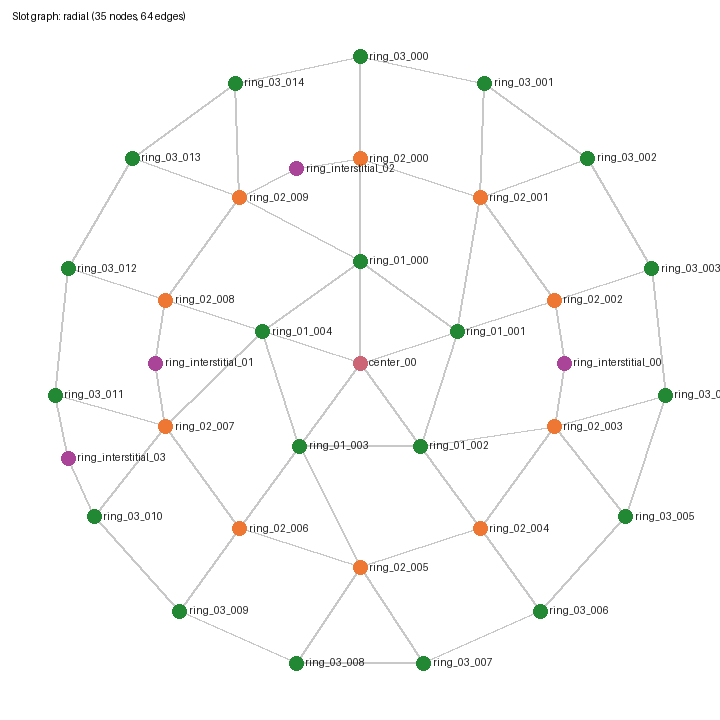

Role counts:
{'center': 1, 'interstitial': 4, 'ring_a': 20, 'ring_b': 10}


In [5]:
display(draw_slot_graph(trace.slot_graph))
print('Role counts:')
role_counts = {}
for node in trace.slot_graph.nodes:
    role_counts[node.role] = role_counts.get(node.role, 0) + 1
pprint(role_counts)


## 3. Assigned graph

Each slot now has one concrete ontology class and stable seeds for class, symbol, and pose sampling.


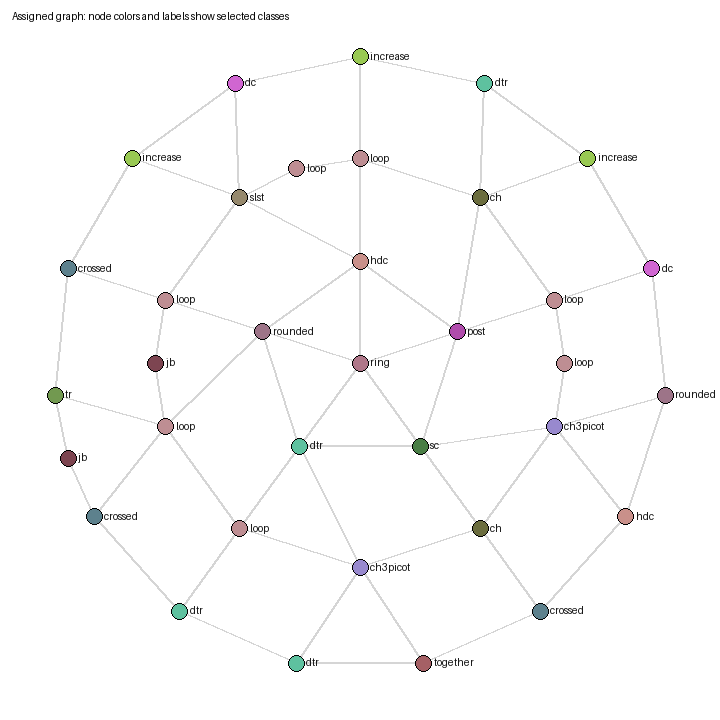

center_00          role=center  class=instructive.ring         symbol_seed=11840507414745325532
ring_01_000        role=ring_a  class=primitive.hdc            symbol_seed=11663917903742838454
ring_01_001        role=ring_a  class=compound.post            symbol_seed=11551419195007543536
ring_01_002        role=ring_a  class=primitive.sc             symbol_seed=18348828221414406390
ring_01_003        role=ring_a  class=primitive.dtr            symbol_seed=9732609924757673558
ring_01_004        role=ring_a  class=compound.rounded         symbol_seed=18336727950491878025
ring_02_000        role=ring_b  class=instructive.loop         symbol_seed=18421907655816578864
ring_02_001        role=ring_b  class=primitive.ch             symbol_seed=15775229660690574979
ring_02_002        role=ring_b  class=instructive.loop         symbol_seed=13882913297294766084
ring_02_003        role=ring_b  class=compound.ch3picot        symbol_seed=16504811931103732979
ring_02_004        role=ring_b  class=pri

In [6]:
display(draw_assigned_graph(trace.assigned_graph))
for node in trace.assigned_graph.nodes:
    print(
        f'{node.slot.slot_id:18} role={node.slot.role:7} '
        f'class={".".join(node.class_key):24} symbol_seed={node.symbol_seed}'
    )


## 4. Realized graph

Every node has an independently sampled upright SVG, transparent raster, and measured local OBB. Red rectangles are the local labels.


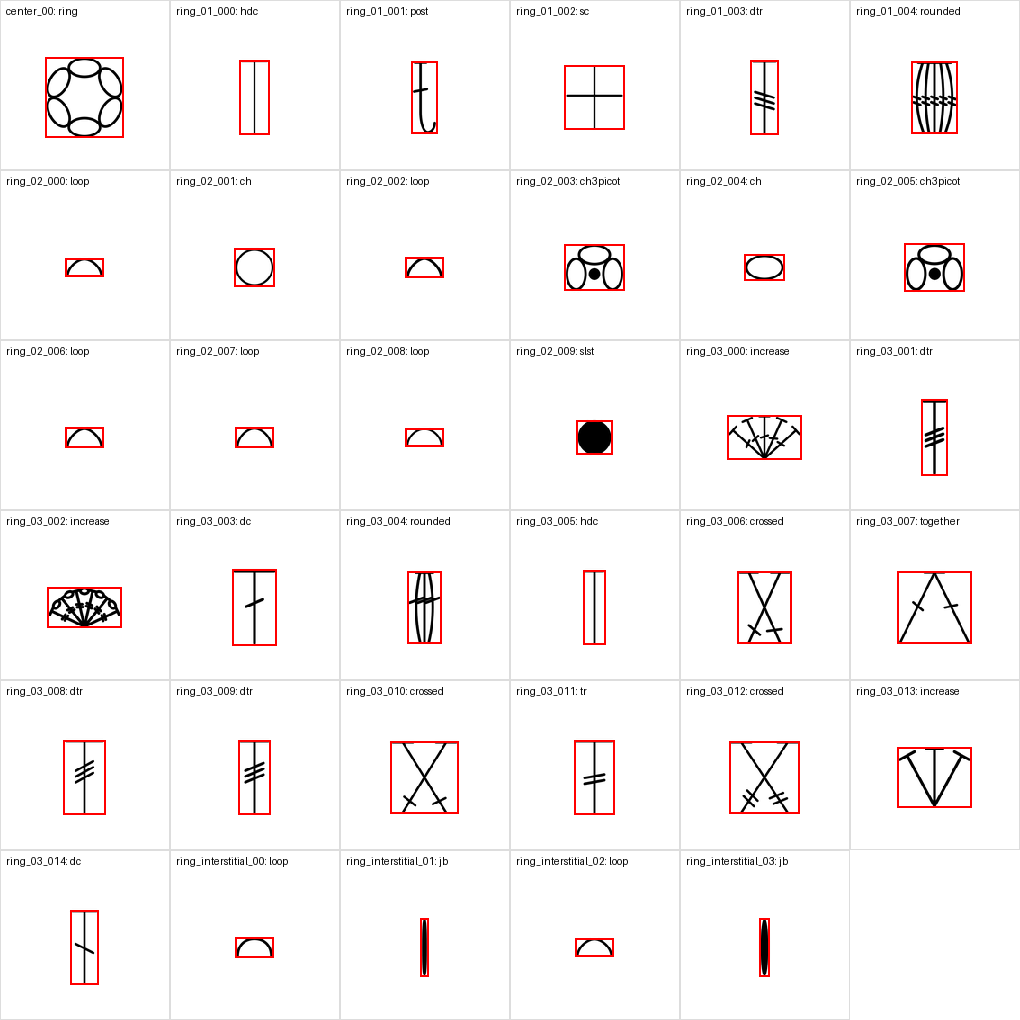

In [7]:
display(draw_realized_contact_sheet(
    trace.realized_graph, columns=contact_sheet_columns
))


## 5. Placed graph and interaction diagnostics

Pattern geometry supplies initial placement. Actual OBBs measure the resulting gaps and overlaps; the pipeline does not silently correct them.


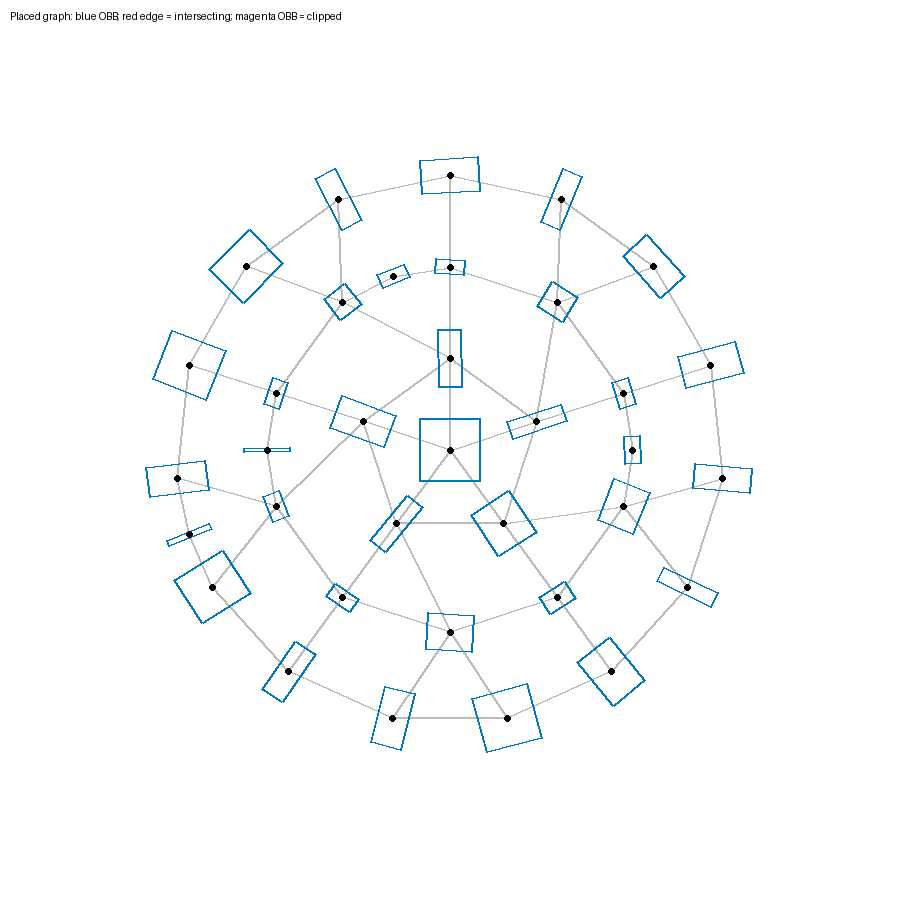

Warnings: none

Node placements:
[{'slot': 'center_00',
  'role': 'center',
  'class': 'instructive.ring',
  'center_px': (640.0, 640.0),
  'rotation_deg': 0.0,
  'visibility': 1.0,
  'symbol_seed': 11840507414745325532},
 {'slot': 'ring_01_000',
  'role': 'ring_a',
  'class': 'primitive.hdc',
  'center_px': (640.0, 510.0),
  'rotation_deg': -0.908,
  'visibility': 1.0,
  'symbol_seed': 11663917903742838454},
 {'slot': 'ring_01_001',
  'role': 'ring_a',
  'class': 'compound.post',
  'center_px': (763.637, 599.828),
  'rotation_deg': 71.697,
  'visibility': 1.0,
  'symbol_seed': 11551419195007543536},
 {'slot': 'ring_01_002',
  'role': 'ring_a',
  'class': 'primitive.sc',
  'center_px': (716.412, 745.172),
  'rotation_deg': 146.309,
  'visibility': 1.0,
  'symbol_seed': 18348828221414406390},
 {'slot': 'ring_01_003',
  'role': 'ring_a',
  'class': 'primitive.dtr',
  'center_px': (563.588, 745.172),
  'rotation_deg': 219.681,
  'visibility': 1.0,
  'symbol_seed': 9732609924757673558},
 {

In [8]:
display(draw_placed_graph(trace.placed_graph))
print('Warnings:', trace.placed_graph.warnings or 'none')
print('\nNode placements:')
pprint(node_rows(trace.placed_graph), sort_dicts=False)


In [9]:
rows = interaction_rows(trace.placed_graph)
intersections = [row for row in rows if row['intersects']]
tightest = sorted(rows, key=lambda row: row['signed_gap_px'])[:25]
print(f'Edges: {len(rows)}; intersecting OBB pairs: {len(intersections)}')
print('Tightest 25 edge relationships:')
pprint(tightest, sort_dicts=False)


Edges: 64; intersecting OBB pairs: 0
Tightest 25 edge relationships:
[{'edge': 'cycle_02_002_after',
  'relationship': 'interstitial_neighbor',
  'source': 'ring_interstitial_00',
  'target': 'ring_02_003',
  'distance_px': 81.346,
  'signed_gap_px': 22.946,
  'overlap_area_px2': 0.0,
  'intersects': False},
 {'edge': 'radial_01_003',
  'relationship': 'center_to_ring',
  'source': 'center_00',
  'target': 'ring_01_003',
  'distance_px': 130.0,
  'signed_gap_px': 26.502,
  'overlap_area_px2': 0.0,
  'intersects': False},
 {'edge': 'radial_01_002',
  'relationship': 'center_to_ring',
  'source': 'center_00',
  'target': 'ring_01_002',
  'distance_px': 130.0,
  'signed_gap_px': 32.315,
  'overlap_area_px2': 0.0,
  'intersects': False},
 {'edge': 'cycle_03_010_before',
  'relationship': 'interstitial_neighbor',
  'source': 'ring_03_010',
  'target': 'ring_interstitial_03',
  'distance_px': 81.532,
  'signed_gap_px': 33.572,
  'overlap_area_px2': 0.0,
  'intersects': False},
 {'edge': 'rad

## 6. Final rendered scene

The final scene SVG is rasterized once. Red polygons show the transformed scene-space OBBs; blue text shows the target class.


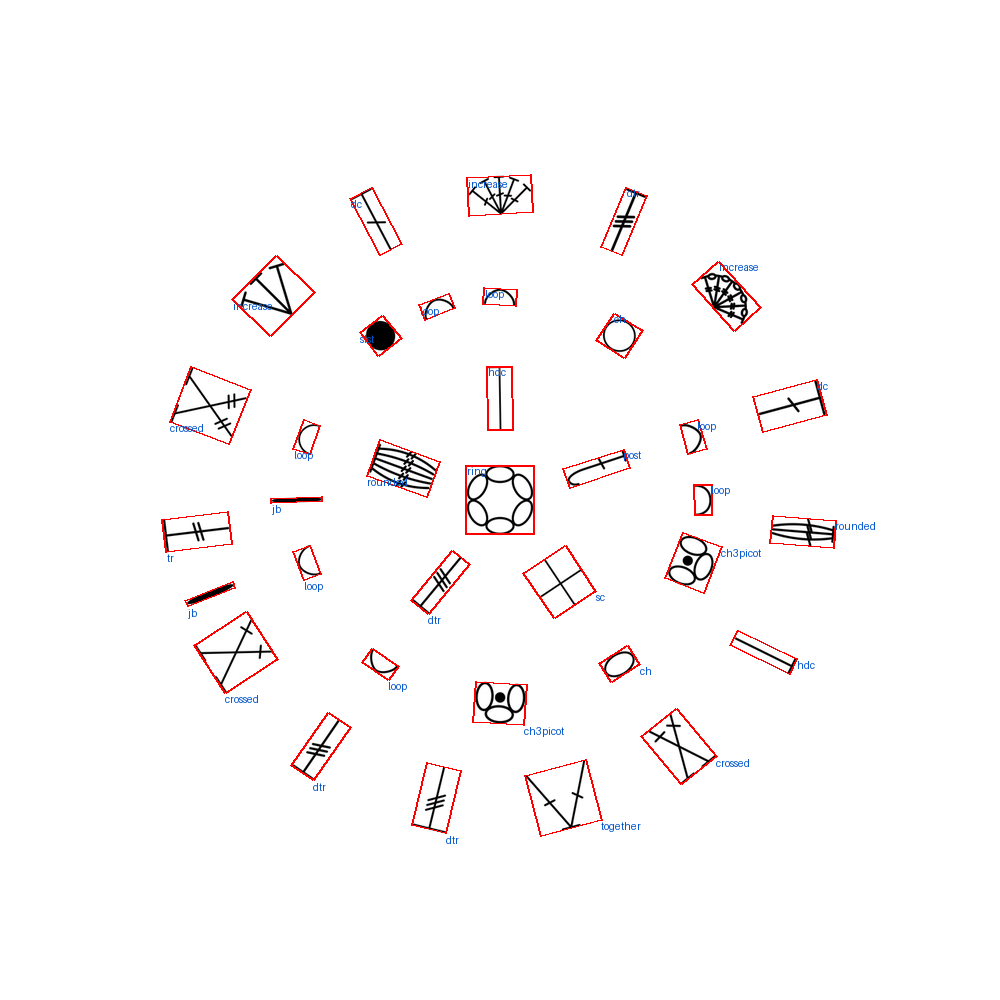

YOLO labels: 35
First five labels:
13 0.46679688 0.46503906 0.53320312 0.46503906 0.53320312 0.53496094 0.46679688 0.53496094
3 0.48757701 0.36640368 0.51140215 0.36602628 0.51242299 0.43047132 0.48859785 0.43084872
9 0.62307122 0.44915921 0.62945020 0.46844408 0.57011214 0.48807172 0.56373315 0.46878684
2 0.59561177 0.59131987 0.55433477 0.61883893 0.52378211 0.57301171 0.56505911 0.54549264
6 0.42801873 0.61410170 0.41118356 0.60013414 0.45258739 0.55022988 0.46942256 0.56419744


In [10]:
display(draw_final_overlay(
    trace.placed_graph, trace.rendered_scene.png_bytes
))
print(f'YOLO labels: {len(trace.rendered_scene.yolo_labels)}')
print('First five labels:')
for label in trace.rendered_scene.yolo_labels[:5]:
    print(label)
